### Описание системы

Рассматривается колл-центр как сеть массового обслуживания, состоящая из двух узлов обработки звонков:

- первая линия операторов;
- вторая линия операторов.

Входящий поток звонков поступает на первую линию с интенсивностью $\lambda$.  
После завершения обслуживания на первой линии звонок:

- с вероятностью $p_{12}$ переводится на вторую линию;
- с вероятностью $1 - p_{12}$ завершает обслуживание и покидает систему.

После завершения обслуживания на второй линии звонок покидает сеть.

В каждом узле работают операторы, которые рассматриваются как каналы обслуживания.  
Каждый оператор обслуживает звонки с интенсивностью $\mu$.  
Число активных операторов изменяется во времени: операторы могут подключаться к работе и отключаться в случайные моменты времени.

Если оператор недоступен, он не принимает звонки.  
Если в линии нет свободных операторов, звонок помещается в очередь.  
Если очередь ограничена и переполнена, звонок теряется.

### Параметры модели

- $\lambda$ — интенсивность входящего потока звонков;
- $\mu$ — интенсивность обслуживания одним оператором;
- $n_{\min}$ — минимальное число активных операторов;
- $n_{\max}$ — максимальное число активных операторов;
- $\alpha$ — интенсивность подключения операторов;
- $\beta$ — интенсивность отключения операторов;
- $T$ — длительность моделирования;
- $N_{\text{runs}}$ — число независимых запусков модели;
- $p_{12}$ — вероятность перевода звонка с первой линии на вторую.

### Исследуемые показатели

В ходе моделирования вычисляются следующие характеристики системы:

- среднее время пребывания звонка в колл-центре;
- среднее число звонков в очереди;
- среднее число активных операторов;
- вероятность потери звонка.

### Формулы и алгоритм работы модели

В имитационной модели используются следующие показатели:

#### Среднее время пребывания звонка в системе
$$
W = \frac{1}{N}\sum_{i=1}^{N} T_i
$$

где:
- $T_i$ — время пребывания $i$-го звонка в колл-центре;
- $N$ — число обслуженных звонков.

#### Среднее число звонков в очереди
$$
L_q = \frac{1}{T} \int_0^T q(t)\,dt
$$

где:
- $q(t)$ — число звонков в очередях в момент времени $t$;
- $T$ — время моделирования.

#### Среднее число активных операторов
$$
\bar{n} = \frac{1}{T} \int_0^T n(t)\,dt
$$

где:
- $n(t)$ — число активных операторов в момент времени $t$.

#### Вероятность потери звонка
$$
P_{\text{loss}} = \frac{N_{\text{loss}}}{N_{\text{total}}}
$$

где:
- $N_{\text{loss}}$ — число потерянных звонков;
- $N_{\text{total}}$ — общее число поступивших звонков.

### Алгоритм работы модели

1. Задаются параметры системы: интенсивность входящего потока звонков, интенсивность обслуживания, диапазон числа операторов, интенсивности подключения и отключения, вероятность перевода звонка между линиями.
2. Формируется поток входящих звонков на первую линию колл-центра.
3. Если на линии есть свободный оператор, звонок сразу поступает на обслуживание.
4. Если все операторы заняты, звонок помещается в очередь.
5. Если очередь заполнена, звонок теряется.
6. После обработки на первой линии часть звонков завершает обслуживание, а часть переводится на вторую линию.
7. На второй линии обслуживание происходит аналогичным образом.
8. В случайные моменты времени операторы могут подключаться к работе или отключаться.
9. Во время моделирования накапливается статистика по времени пребывания звонков, длине очередей, числу активных операторов и потерям.
10. Моделирование повторяется многократно, после чего результаты усредняются.

In [1]:
import math
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lambda_calls = 10
mu_service = 3

min_operators = 1
max_operators = 5

operator_on_rate = 1.0
operator_off_rate = 0.5

simulation_time = 1000
n_runs = 100

p_transfer = 0.4
queue_limit = 30

In [3]:
class DynamicCallLine:
    def __init__(self, env, mu_service, min_operators, max_operators, operator_on_rate, operator_off_rate, queue_limit, rng):
        self.env = env
        self.mu_service = mu_service
        self.min_operators = min_operators
        self.max_operators = max_operators
        self.operator_on_rate = operator_on_rate
        self.operator_off_rate = operator_off_rate
        self.queue_limit = queue_limit
        self.rng = rng

        self.active_operators = min_operators
        self.busy_operators = 0
        self.queue = []

        self.queue_area = 0.0
        self.operators_area = 0.0
        self.last_event_time = 0.0

        env.process(self.operator_dynamics())

    def update_time_stats(self):
        dt = self.env.now - self.last_event_time
        if dt > 0:
            self.queue_area += len(self.queue) * dt
            self.operators_area += self.active_operators * dt
            self.last_event_time = self.env.now

    def operator_dynamics(self):
        while True:
            t_on = self.rng.exponential(1 / self.operator_on_rate) if self.operator_on_rate > 0 else np.inf
            t_off = self.rng.exponential(1 / self.operator_off_rate) if self.operator_off_rate > 0 else np.inf

            if t_on < t_off:
                yield self.env.timeout(t_on)
                self.update_time_stats()
                if self.active_operators < self.max_operators:
                    self.active_operators += 1
                    self.try_start_service()
            else:
                yield self.env.timeout(t_off)
                self.update_time_stats()
                if self.active_operators > self.min_operators and self.busy_operators < self.active_operators:
                    self.active_operators -= 1

    def try_start_service(self):
        while self.queue and self.busy_operators < self.active_operators:
            item = self.queue.pop(0)
            self.busy_operators += 1
            self.env.process(self.serve(item))

    def serve(self, item):
        arrival_time, done_event = item
        service_time = self.rng.exponential(1 / self.mu_service)
        yield self.env.timeout(service_time)
        self.update_time_stats()
        self.busy_operators -= 1
        done_event.succeed(self.env.now)
        self.try_start_service()

    def request_service(self, arrival_time):
        self.update_time_stats()

        if self.busy_operators < self.active_operators:
            done_event = self.env.event()
            self.busy_operators += 1
            self.env.process(self.serve((arrival_time, done_event)))
            return done_event, False, False

        if len(self.queue) >= self.queue_limit:
            return None, False, True

        done_event = self.env.event()
        self.queue.append((arrival_time, done_event))
        return done_event, True, False


def simulate_call_center_network(lambda_calls, mu_service, min_operators, max_operators, operator_on_rate, operator_off_rate, simulation_time, p_transfer, queue_limit, random_state=None):
    rng = np.random.default_rng(random_state)
    env = simpy.Environment()

    first_line = DynamicCallLine(env, mu_service, min_operators, max_operators, operator_on_rate, operator_off_rate, queue_limit, rng)
    second_line = DynamicCallLine(env, mu_service, min_operators, max_operators, operator_on_rate, operator_off_rate, queue_limit, rng)

    total_calls = 0
    lost_calls = 0
    network_times = []
    calls_in_system = 0
    source_finished = False

    def source():
        nonlocal total_calls, calls_in_system, source_finished

        while True:
            interarrival = rng.exponential(1 / lambda_calls)
            yield env.timeout(interarrival)

            if env.now > simulation_time:
                source_finished = True
                break

            total_calls += 1
            calls_in_system += 1
            env.process(handle_call(env.now))

    def handle_call(arrival_time):
        nonlocal lost_calls, calls_in_system

        system_entry = arrival_time

        done1, waited1, lost1 = first_line.request_service(arrival_time)

        if lost1:
            lost_calls += 1
            calls_in_system -= 1
            return

        finish1 = yield done1

        if rng.random() < p_transfer:
            done2, waited2, lost2 = second_line.request_service(finish1)

            if lost2:
                lost_calls += 1
                calls_in_system -= 1
                return

            finish2 = yield done2
            network_times.append(finish2 - system_entry)
        else:
            network_times.append(finish1 - system_entry)

        calls_in_system -= 1

    def stop_condition():
        while True:
            if source_finished and calls_in_system == 0:
                break
            yield env.timeout(1)

    env.process(source())
    env.run(until=env.process(stop_condition()))

    total_time = env.now
    first_line.update_time_stats()
    second_line.update_time_stats()

    avg_queue = (first_line.queue_area + second_line.queue_area) / total_time if total_time > 0 else 0.0
    avg_operators = (first_line.operators_area + second_line.operators_area) / total_time if total_time > 0 else 0.0
    avg_network_time = np.mean(network_times) if network_times else 0.0
    p_loss = lost_calls / total_calls if total_calls > 0 else 0.0

    return {
        "total_calls": total_calls,
        "lost_calls": lost_calls,
        "avg_network_time": avg_network_time,
        "avg_queue": avg_queue,
        "avg_operators": avg_operators,
        "p_loss": p_loss,
        "total_time": total_time
    }



In [4]:
def run_multiple_simulations(lambda_calls, mu_service, min_operators, max_operators, operator_on_rate, operator_off_rate, simulation_time, p_transfer, queue_limit, n_runs):
    results = []

    for run in range(n_runs):
        result = simulate_call_center_network(
            lambda_calls=lambda_calls,
            mu_service=mu_service,
            min_operators=min_operators,
            max_operators=max_operators,
            operator_on_rate=operator_on_rate,
            operator_off_rate=operator_off_rate,
            simulation_time=simulation_time,
            p_transfer=p_transfer,
            queue_limit=queue_limit,
            random_state=run
        )
        results.append(result)

    df = pd.DataFrame(results)

    summary = pd.DataFrame({
        "Показатель": [
            "Среднее время пребывания звонка в колл-центре",
            "Среднее число звонков в очереди",
            "Среднее число активных операторов",
            "Вероятность потери звонков"
        ],
        "Имитация": [
            df["avg_network_time"].mean(),
            df["avg_queue"].mean(),
            df["avg_operators"].mean(),
            df["p_loss"].mean()
        ]
    })

    return df, summary

In [5]:
runs_df, summary_df = run_multiple_simulations(
    lambda_calls=lambda_calls,
    mu_service=mu_service,
    min_operators=min_operators,
    max_operators=max_operators,
    operator_on_rate=operator_on_rate,
    operator_off_rate=operator_off_rate,
    simulation_time=simulation_time,
    p_transfer=p_transfer,
    queue_limit=queue_limit,
    n_runs=n_runs
)

summary_df

,Показатель,Имитация
0,Среднее время пребывания звонка в колл-центре,0.600708
1,Среднее число звонков в очереди,1.338511
2,Среднее число активных операторов,8.895128
3,Вероятность потери звонков,0.000124


In [6]:
runs_df.describe()

,total_calls,lost_calls,avg_network_time,avg_queue,avg_operators,p_loss,total_time
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,9999.060000,1.240000,0.600708,1.338511,8.895128,0.000124,1001.530000
std,102.607699,3.646279,0.019569,0.181259,0.069352,0.000363,0.610597
min,9670.000000,0.000000,0.556739,0.974295,8.762741,0.000000,1001.000000
25%,9936.250000,0.000000,0.589782,1.231667,8.839744,0.000000,1001.000000
50%,10001.500000,0.000000,0.598120,1.326154,8.890101,0.000000,1001.000000
75%,10052.750000,0.000000,0.613795,1.436715,8.945944,0.000000,1002.000000
max,10263.000000,24.000000,0.667080,1.970918,9.035306,0.002361,1003.000000


In [7]:
on_rate_range = np.arange(0.2, 2.2, 0.2)
network_results = []

for on_rate in on_rate_range:
    runs_df_exp, summary_df_exp = run_multiple_simulations(
        lambda_calls=lambda_calls,
        mu_service=mu_service,
        min_operators=min_operators,
        max_operators=max_operators,
        operator_on_rate=on_rate,
        operator_off_rate=operator_off_rate,
        simulation_time=simulation_time,
        p_transfer=p_transfer,
        queue_limit=queue_limit,
        n_runs=n_runs
    )

    values = dict(zip(summary_df_exp["Показатель"], summary_df_exp["Имитация"]))

    network_results.append({
        "operator_on_rate": on_rate,
        "avg_operators": values["Среднее число активных операторов"],
        "avg_network_time": values["Среднее время пребывания звонка в колл-центре"],
        "avg_queue": values["Среднее число звонков в очереди"],
        "p_loss": values["Вероятность потери звонков"]
    })

df_network = pd.DataFrame(network_results)
df_network



,operator_on_rate,avg_operators,avg_network_time,avg_queue,p_loss
0,0.2,5.986872,1.495989,10.008587,0.023134
1,0.4,7.281730,0.902525,4.331455,0.005076
2,0.6,8.096473,0.709900,2.435202,0.001356
3,0.8,8.574847,0.640141,1.737250,0.000441
4,1.0,8.895128,0.600708,1.338511,0.000124
5,1.2,9.098761,0.579356,1.124457,0.000070
6,1.4,9.244305,0.567185,1.010295,0.000058
7,1.6,9.352729,0.557467,0.912841,0.000020
8,1.8,9.439891,0.551426,0.851866,0.000015
9,2.0,9.501908,0.548699,0.819755,0.000000


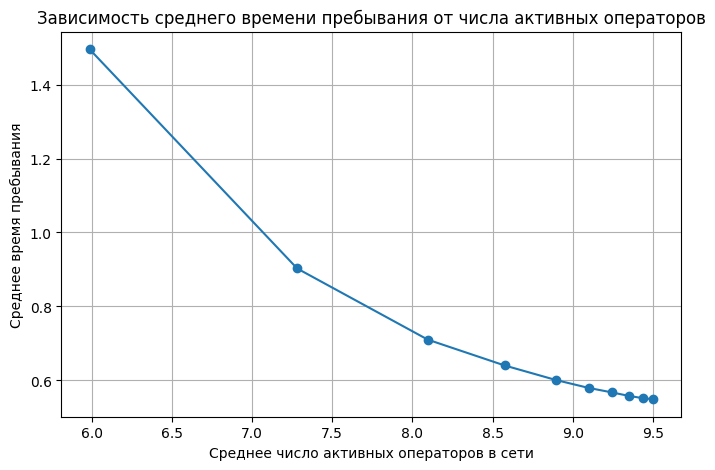

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(df_network["avg_operators"], df_network["avg_network_time"], marker="o")

plt.xlabel("Среднее число активных операторов в сети")
plt.ylabel("Среднее время пребывания")
plt.title("Зависимость среднего времени пребывания от числа активных операторов")

plt.grid(True)
plt.show()



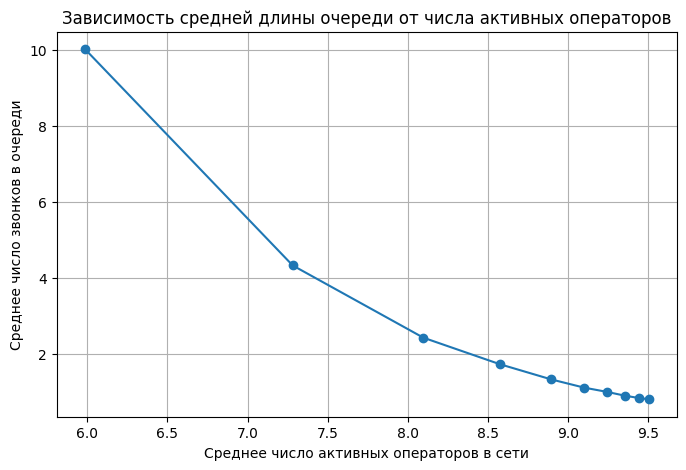

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(df_network["avg_operators"], df_network["avg_queue"], marker="o")

plt.xlabel("Среднее число активных операторов в сети")
plt.ylabel("Среднее число звонков в очереди")
plt.title("Зависимость средней длины очереди от числа активных операторов")

plt.grid(True)
plt.show()



## Анализ результатов

Результаты моделирования показывают, что динамика числа активных операторов существенно влияет на эффективность работы колл-центра.

При увеличении среднего числа активных операторов:

- уменьшается среднее время пребывания звонка в колл-центре;
- уменьшается среднее число звонков в очереди;
- снижается вероятность потери звонков.

Это объясняется тем, что при большем числе работающих операторов возрастает суммарная производительность линий обслуживания, вследствие чего звонки быстрее проходят обработку и реже накапливаются в очередях.

Если интенсивность подключения операторов мала, а интенсивность отключения велика, колл-центр чаще оказывается в состоянии недостатка персонала.  
В этом случае увеличивается нагрузка на активных операторов, растут очереди и ухудшается качество обслуживания клиентов.

## Выводы

В данной работе была построена имитационная модель сети массового обслуживания, описывающая работу колл-центра с динамически изменяющимся числом операторов.

В модели рассматривались две линии обслуживания звонков, между которыми часть обращений переводилась после первичной обработки.  
Операторы могли подключаться и отключаться в случайные моменты времени, что позволяло исследовать влияние изменения числа доступных каналов обслуживания на характеристики системы.

В результате моделирования были определены:

- среднее время пребывания звонка в колл-центре;
- среднее число звонков в очереди;
- среднее число активных операторов;
- вероятность потери звонков.

По результатам анализа установлено:

1. Увеличение числа активных операторов приводит к уменьшению времени пребывания звонков в системе.
2. При росте числа активных операторов уменьшается длина очереди.
3. Вероятность потери звонков снижается при увеличении доступного числа операторов.
4. Динамика подключения и отключения операторов существенно влияет на устойчивость и эффективность работы колл-центра.

Следовательно, для повышения эффективности работы колл-центра необходимо поддерживать достаточное число активных операторов и ограничивать частоту их отключения.